In [ ]:
!pip install xgboost
!pip install imbalanced-learn

In [ ]:
# ============================================
# IMPORTING REQUIRED LIBRARIES
# ============================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# Handling Imbalance
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ============================================
# LOADING DATASET
# ============================================

# Load dataset

df = pd.read_csv('/content/credit_card_fraud_10k.csv')

# Display first 5 rows
print(df.head())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [ ]:
# ============================================
# BASIC DATASET INFORMATION
# ============================================

# Shape of dataset
print("Dataset Shape:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
print(df.info())

Dataset Shape:
(10000, 10)

Columns:
Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: fl

In [ ]:
# ============================================
# CHECKING MISSING VALUES
# ============================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


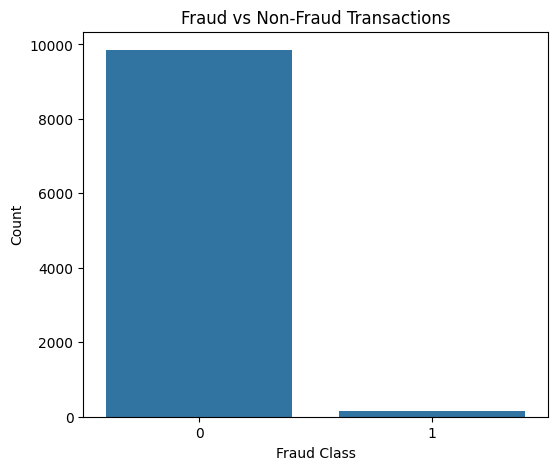

In [ ]:
# ============================================
# VISUALIZING FRAUD VS NON-FRAUD TRANSACTIONS
# ============================================

plt.figure(figsize=(6,5))

sns.countplot(x='is_fraud', data=df)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Class')
plt.ylabel('Count')

plt.show()

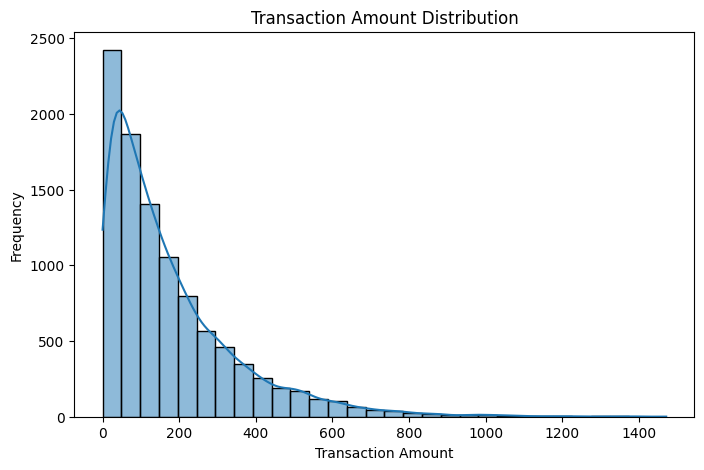

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['amount'], bins=30, kde=True)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

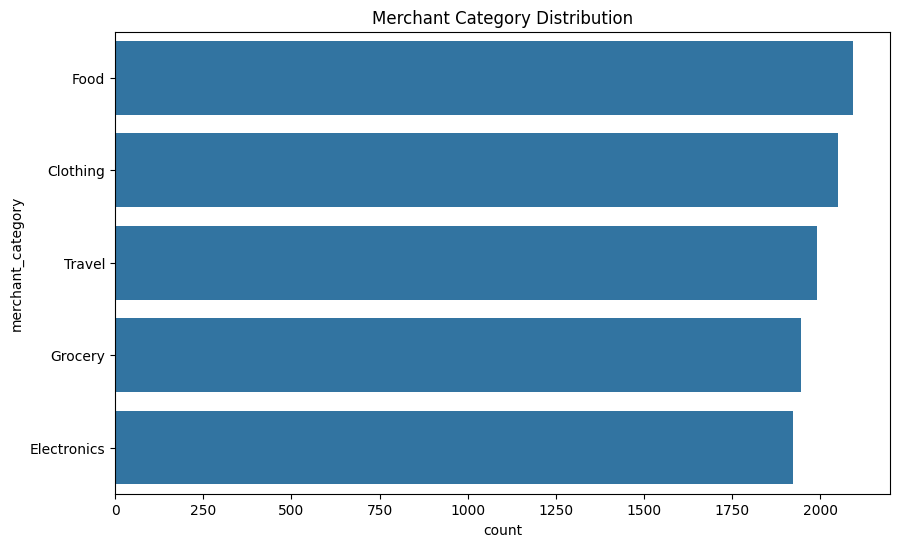

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='merchant_category',
    data=df,
    order=df['merchant_category'].value_counts().index
)

plt.title('Merchant Category Distribution')

plt.show()

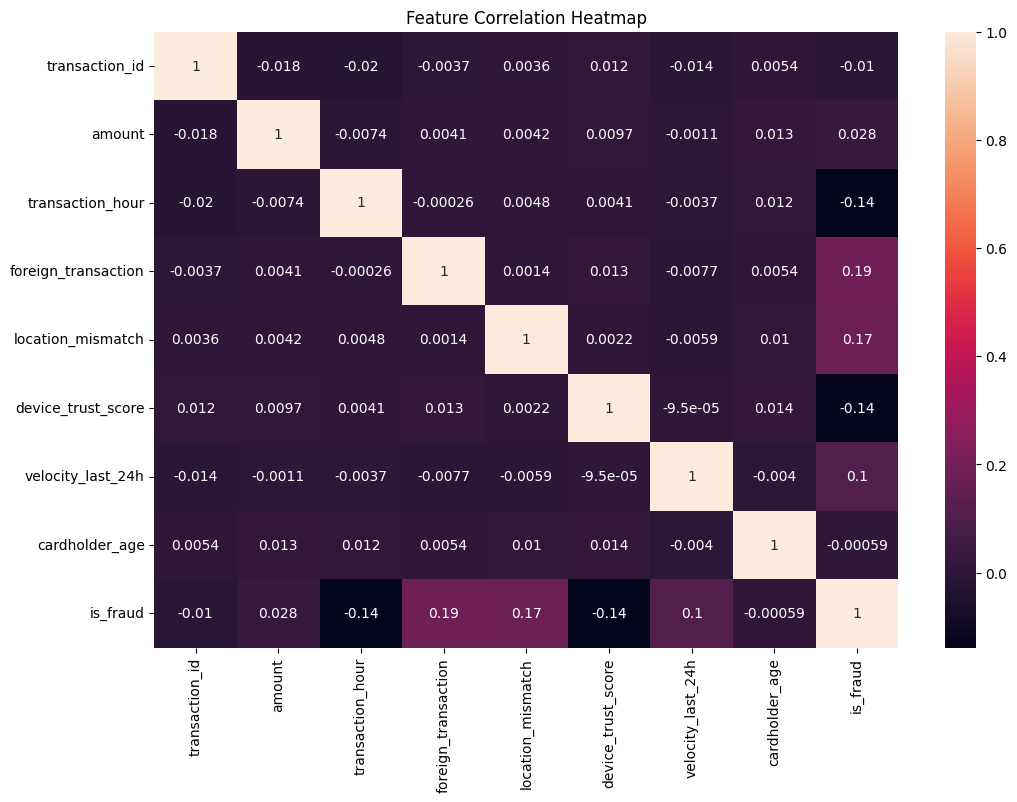

In [ ]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True)

plt.title('Feature Correlation Heatmap')

plt.show()

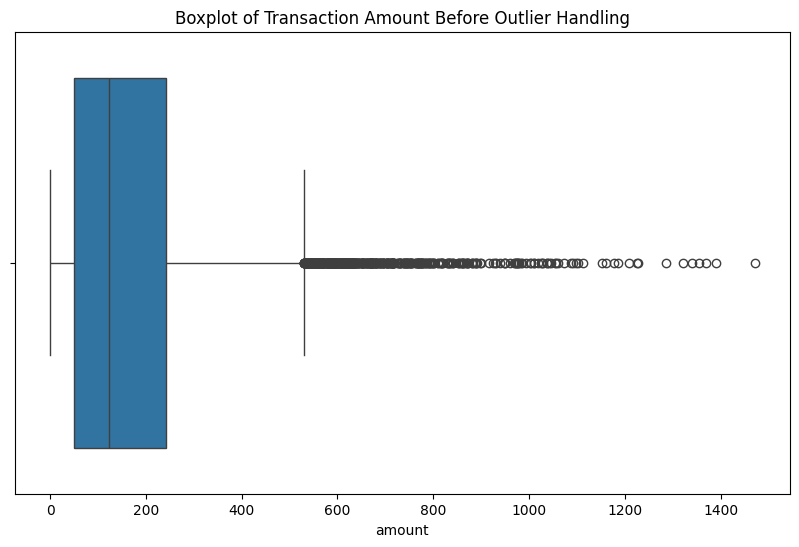

In [ ]:
# ============================================
# OUTLIER VISUALIZATION BEFORE HANDLING
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(x=df['amount'])

plt.title('Boxplot of Transaction Amount Before Outlier Handling')

plt.show()

In [ ]:
# ============================================
# DETECTING OUTLIERS USING IQR METHOD
# ============================================

Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Lower Bound: -236.45749999999995
Upper Bound: 529.8425


In [ ]:
# ============================================
# REMOVING OUTLIERS
# ============================================

outlier_removed_df = df[
    (df['amount'] >= lower_bound) &
    (df['amount'] <= upper_bound)
]

print('Original Shape:', df.shape)
print('Shape After Removing Outliers:', outlier_removed_df.shape)

Original Shape: (10000, 10)
Shape After Removing Outliers: (9499, 10)


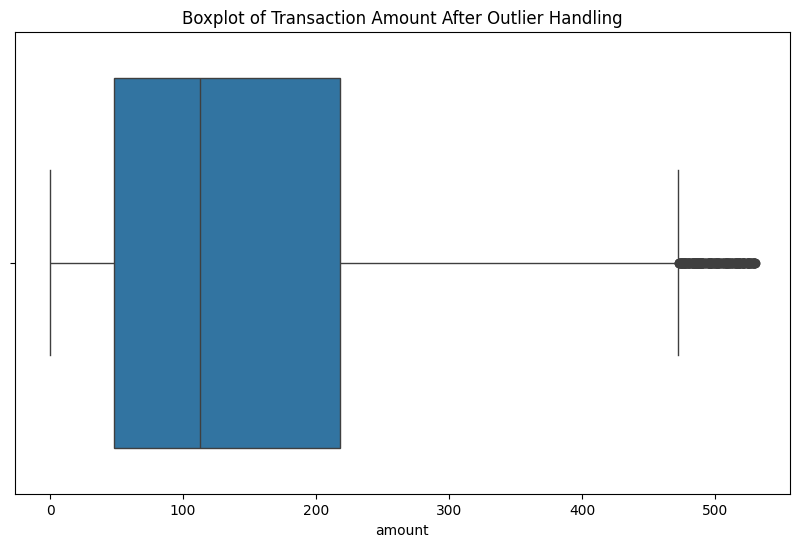

In [ ]:
# ============================================
# OUTLIER VISUALIZATION AFTER HANDLING
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(x=outlier_removed_df['amount'])

plt.title('Boxplot of Transaction Amount After Outlier Handling')

plt.show()

In [ ]:
# ============================================
# USING CLEANED DATASET
# ============================================

df = outlier_removed_df.copy()

In [ ]:
# ============================================
# ENCODING CATEGORICAL VARIABLES
# ============================================

label_encoder = LabelEncoder()

categorical_columns = ['merchant_category']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

   transaction_id  amount  transaction_hour  merchant_category  \
0               1   84.47                22                  1   
2               3  237.01                17                  3   
3               4  164.33                 4                  3   
4               5   30.53                15                  2   
5               6   30.53                13                  0   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   
5                    0                  0                  90   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
2                  1              61         0  
3                  3              34         0  
4               

In [ ]:
# ============================================
# SEPARATING FEATURES AND TARGET VARIABLE
# ============================================

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# ============================================
# SPLITTING DATA INTO TRAINING AND TESTING SETS
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (7599, 9)
Testing Shape: (1900, 9)


Before SMOTE:
is_fraud
0    7490
1     109
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7490
1    7490
Name: count, dtype: int64


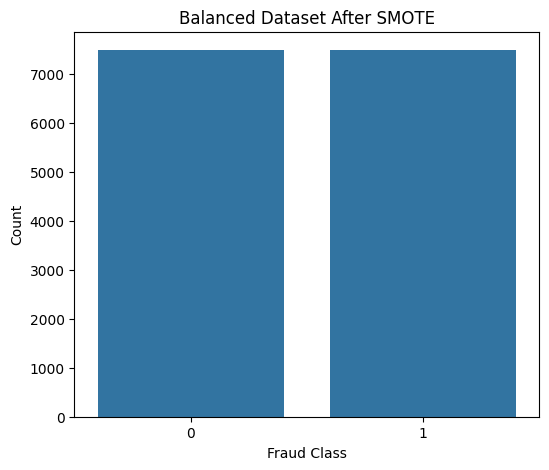

In [ ]:
# ============================================
# HANDLING IMBALANCED DATA USING SMOTE
# ============================================

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())
plt.figure(figsize=(6,5))

sns.countplot(x=y_train_smote)

plt.title('Balanced Dataset After SMOTE')
plt.xlabel('Fraud Class')
plt.ylabel('Count')

plt.show()

In [ ]:
# ============================================
# LOGISTIC REGRESSION MODEL
# ============================================

lr_model = LogisticRegression()

lr_model.fit(X_train_smote, y_train_smote)

lr_pred = lr_model.predict(X_test)

# ============================================
# RANDOM FOREST MODEL
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)

# ============================================
# XGBOOST MODEL (PROPOSED MODEL)
# ============================================

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_test)

In [ ]:
# ============================================
# MODEL EVALUATION FUNCTION
# ============================================

# This function calculates:
# Accuracy
# Precision
# Recall
# F1-score
# ROC-AUC
# Confusion Matrix


def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_pred)

    print("\n====================================")
    print(f"{model_name} Performance")
    print("====================================")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(cm, annot=True, fmt='d')

    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()


    evaluate_model(
    'Logistic Regression',
    y_test,
    lr_pred
)

    evaluate_model(
    'Random Forest',
    y_test,
    rf_pred
)

    evaluate_model(
    'XGBoost',
    y_test,
    xgb_pred
)

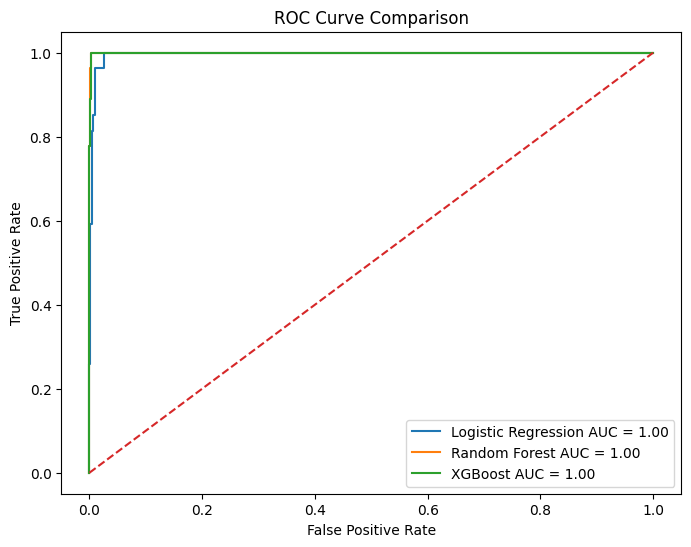

In [ ]:
# ============================================
# ROC CURVE VISUALIZATION
# ============================================

# Predict probabilities
lr_probs = lr_model.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# AUC Scores
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Plot ROC Curves
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression AUC = {lr_auc:.2f}')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest AUC = {rf_auc:.2f}')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost AUC = {xgb_auc:.2f}')

plt.plot([0,1],[0,1],'--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

In [ ]:
# ============================================
# MODEL PERFORMANCE COMPARISON TABLE
# ============================================

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.974737   0.360000  1.000000  0.529412
1        Random Forest  0.996316   0.916667  0.814815  0.862745
2              XGBoost  0.996842   0.888889  0.888889  0.888889


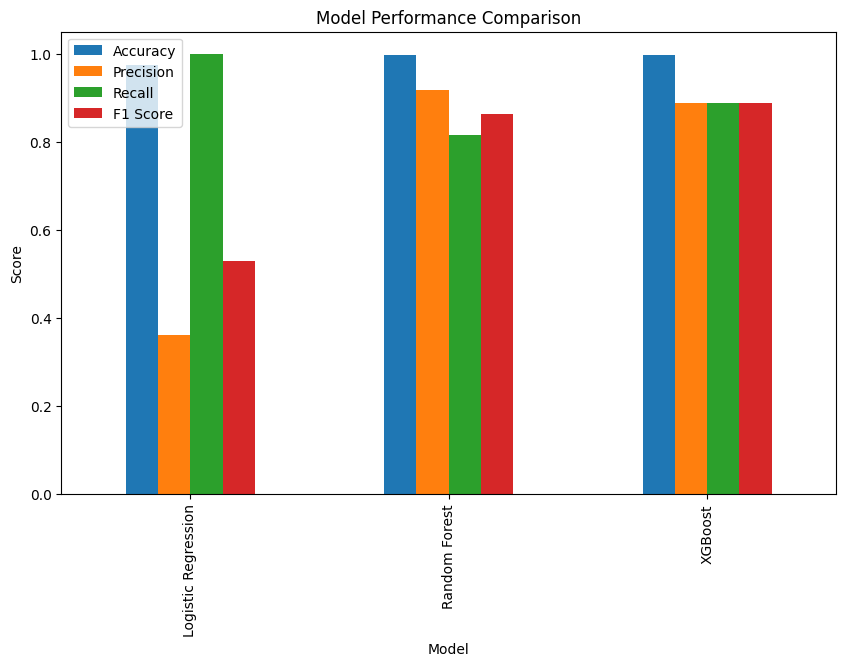

In [ ]:
results.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')

plt.show()

In [ ]:
# ============================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================

importance = xgb_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

               Feature  Importance
2     transaction_hour    0.269289
5    location_mismatch    0.266594
6   device_trust_score    0.148258
4  foreign_transaction    0.142113
7    velocity_last_24h    0.111104
3    merchant_category    0.020836
0       transaction_id    0.015180
8       cardholder_age    0.014367
1               amount    0.012258


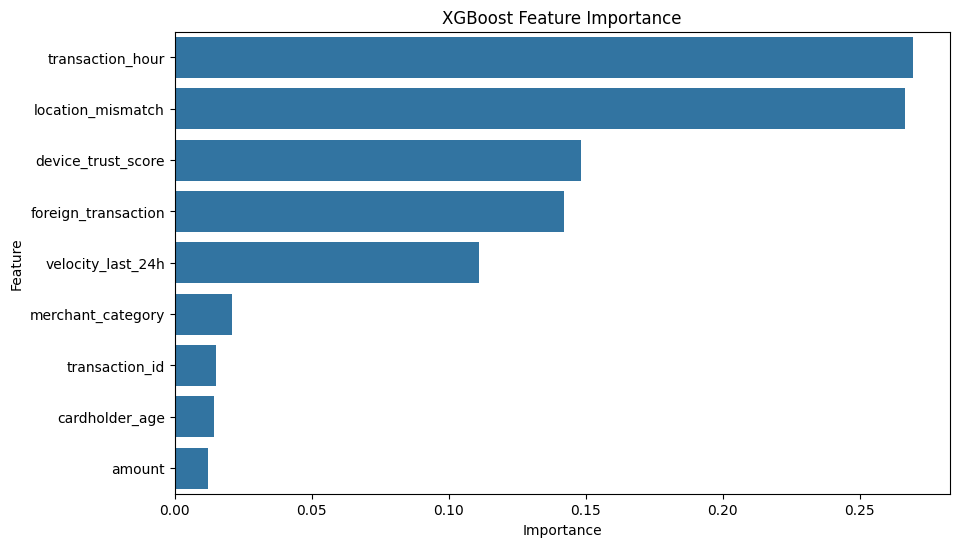

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('XGBoost Feature Importance')

plt.show()

In [ ]:
print("====================================")
print("FINAL PROJECT CONCLUSION")
print("====================================")

print("Best Performing Model: XGBoost")
print("Reason:")
print("- Highest fraud detection capability")
print("- Better recall and F1-score")
print("- Handles imbalanced data effectively")
print("- Improved using SMOTE balancing")

FINAL PROJECT CONCLUSION
Best Performing Model: XGBoost
Reason:
- Highest fraud detection capability
- Better recall and F1-score
- Handles imbalanced data effectively
- Improved using SMOTE balancing
